# Disease Prediction — Exploration and Leakage Analysis

This notebook is the analysis behind the project's central claim: the **100% accuracy**
this dataset produces under a standard train/test split is a property of the *data*, not
an achievement of the *model*.

It walks through:

1. Loading and inspecting the symptom → prognosis table
2. Reproducing the suspicious 100%
3. Auditing the dataset to find out why
4. Fixing the evaluation with a leakage-aware split protocol
5. Asking whether gradient boosting earns its complexity here
6. Measuring robustness to imperfect symptom reporting
7. Explaining individual predictions

Every step calls into the `disease_predictor` package, so the notebook and the
production pipeline cannot drift apart — the same code produces both.

> ⚠️ **Educational project. Not a medical device and not medical advice.**

## Setup

If the real dataset is not present, everything below falls back to the package's
synthetic generator, which reproduces the same structure *and the same duplicate-row
failure mode*. The banner printed by the next cell says which one is in use.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Allow running from a checkout without installing the package.
if (Path.cwd().parent / "src").is_dir():
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from disease_predictor.data import (
    DatasetNotFoundError,
    audit_duplicates,
    load_dataset,
    pattern_groups,
)
from disease_predictor.evaluation import (
    benchmark_models,
    classification_metrics,
    compare_split_protocols,
    make_split,
    robustness_curve,
)
from disease_predictor.explain import explain_prediction, global_importance
from disease_predictor.models import available_models, build_pipeline

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
try:
    dataset = load_dataset()
    USING_REAL_DATA = True
except DatasetNotFoundError:
    dataset = load_dataset(synthetic=True)
    USING_REAL_DATA = False

banner = "REAL DATASET" if USING_REAL_DATA else "SYNTHETIC DATA (generated - not real clinical data)"
print("=" * 78)
print(f"  DATA SOURCE: {banner}")
print("=" * 78)
for key, value in dataset.describe().items():
    print(f"  {key:<22} {value}")

  DATA SOURCE: SYNTHETIC DATA (generated - not real clinical data)
  source                 synthetic (generated, not real clinical data)
  n_rows                 720
  n_features             48
  n_classes              12
  rows_per_class_min     52
  rows_per_class_max     70
  imbalance_ratio        1.346
  fingerprint            be701fa54adc2be2


## 1. What the data looks like

Every symptom is a binary indicator; the target is a disease name.

In [3]:
display(dataset.frame.iloc[:5, :8])

X = dataset.features
y_text = dataset.labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print(f"Feature matrix : {X.shape}")
print(f"Diseases       : {dataset.n_classes}")
print(f"Symptoms/row   : min={X.sum(axis=1).min()}, mean={X.sum(axis=1).mean():.1f}, max={X.sum(axis=1).max()}")

,synthetic_symptom_000,synthetic_symptom_001,synthetic_symptom_002,synthetic_symptom_003,synthetic_symptom_004,synthetic_symptom_005,synthetic_symptom_006,synthetic_symptom_007
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0


Feature matrix : (720, 48)
Diseases       : 12
Symptoms/row   : min=2, mean=5.1, max=9


In [4]:
counts = pd.Series(y_text).value_counts()
print("Rows per disease")
print(f"  min {counts.min()} | max {counts.max()} | unique counts: {sorted(counts.unique())}")

if counts.nunique() == 1:
    print(f"\n  -> EXACTLY {counts.iloc[0]} rows for every disease.")
    print("     Perfect balance to the row is not something real prevalence produces.")
    print("     It also means class-imbalance handling (SMOTE) has nothing to correct here.")

Rows per disease
  min 52 | max 70 | unique counts: [np.int64(52), np.int64(53), np.int64(55), np.int64(57), np.int64(58), np.int64(61), np.int64(62), np.int64(63), np.int64(65), np.int64(69), np.int64(70)]


## 2. Reproducing the suspicious result

The textbook approach: stratified random split, gradient boosting, measure accuracy.

In [5]:
model_name = "xgboost" if "xgboost" in available_models() else "random_forest"

naive_split = make_split(X, y, strategy="random", test_size=0.2, random_state=42)
naive_model = build_pipeline(model_name, random_state=42)
naive_model.fit(X[naive_split.train], y[naive_split.train])

naive_metrics = classification_metrics(
    y[naive_split.test],
    naive_model.predict(X[naive_split.test]),
    naive_model.predict_proba(X[naive_split.test]),
    n_classes=dataset.n_classes,
)
print(f"Model: {model_name}   (stratified random split)")
for key, value in naive_metrics.items():
    print(f"  {key:<28} {value}")

Model: xgboost   (stratified random split)
  accuracy                     1.0
  balanced_accuracy            1.0
  macro_f1                     1.0
  weighted_f1                  1.0
  top_3_accuracy               1.0
  expected_calibration_error   0.051271
  log_loss                     0.056902


A near-perfect score, reproducible under cross-validation. Before treating that as
success, it is worth asking what the test set actually contains.

## 3. The audit: how much of this dataset is repetition?

`audit_duplicates` compares rows against each other and against the label.

In [6]:
audit = audit_duplicates(dataset)
for key, value in audit.items():
    print(f"  {key:<30} {value}")

  n_rows                         720
  n_unique_rows                  382
  n_duplicate_rows               338
  duplicate_row_fraction         0.4694
  n_unique_patterns              382
  rows_per_unique_pattern        1.88
  patterns_per_class             31.83
  n_ambiguous_patterns           0
  ambiguous_pattern_fraction     0.0
  leakage_risk                   0.6611
  mean_symptoms_per_row          5.1
  min_symptoms_per_row           2
  max_symptoms_per_row           9


In [7]:
duplicate_fraction = float(audit["duplicate_row_fraction"])
leakage_risk = float(audit["leakage_risk"])

print(f"{duplicate_fraction:.1%} of rows are an exact repeat of an earlier row.")
print(f"{audit['n_rows']} rows collapse to {audit['n_unique_patterns']} distinct symptom patterns")
print(f"  -> the effective sample size is {audit['n_unique_patterns']}, not {audit['n_rows']}.")
print()
print(f"{leakage_risk:.1%} of rows have at least one identical twin elsewhere in the table.")
print("A random split shuffles ROWS, not PATTERNS, so those twins are divided between")
print("train and test. Reproducing them is memorisation being scored as generalisation.")
print()
print(f"Symptom patterns mapping to more than one disease: {audit['n_ambiguous_patterns']}")
print("  -> with (almost) none, the Bayes error is ~0 and the ceiling really is 100%.")

46.9% of rows are an exact repeat of an earlier row.
720 rows collapse to 382 distinct symptom patterns
  -> the effective sample size is 382, not 720.

66.1% of rows have at least one identical twin elsewhere in the table.
A random split shuffles ROWS, not PATTERNS, so those twins are divided between
train and test. Reproducing them is memorisation being scored as generalisation.

Symptom patterns mapping to more than one disease: 0
  -> with (almost) none, the Bayes error is ~0 and the ceiling really is 100%.


In [8]:
# Concretely: find a pattern that appears many times and show where its copies land.
groups = pattern_groups(X)
group_sizes = pd.Series(groups).value_counts()
most_repeated = group_sizes.index[0]
rows = np.flatnonzero(groups == most_repeated)

print(f"The most repeated symptom pattern appears {len(rows)} times, all labelled "
      f"'{y_text[rows[0]]}'.")

in_train = np.isin(rows, naive_split.train).sum()
in_test = np.isin(rows, naive_split.test).sum()
print(f"Under the random split above: {in_train} copies in TRAIN, {in_test} in TEST.")
if in_train and in_test:
    print("  -> every one of those test rows was already seen verbatim during training.")

The most repeated symptom pattern appears 17 times, all labelled 'Synthetic Condition 06'.
Under the random split above: 15 copies in TRAIN, 2 in TEST.
  -> every one of those test rows was already seen verbatim during training.


## 4. The fix: a grouped split protocol

Assign each distinct symptom vector a group id, then split on **groups** rather than
rows (`StratifiedGroupKFold`). Identical rows can no longer straddle the boundary, so
the score measures generalisation to unseen symptom patterns.

`compare_split_protocols` runs both on the raw data and reports the difference.

In [9]:
comparison = compare_split_protocols(
    build_pipeline(model_name, random_state=42), X, y, groups, n_splits=5, random_state=42
)
display(comparison[[c for c in comparison.columns if c.endswith("_mean")]].round(4))

gap = comparison.loc["leakage_gap", "accuracy_mean"]
print(f"\nLeakage gap: {gap:+.4f} accuracy")
print("That is score the random protocol hands over for free.")

,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,weighted_f1_mean,top_3_accuracy_mean,expected_calibration_error_mean,log_loss_mean
protocol,,,,,,,
random,0.9944,0.9946,0.9945,0.9944,0.9986,0.0524,0.0690
grouped,0.9861,0.9854,0.9858,0.9860,1.0000,0.0678,0.1109
leakage_gap,0.0083,0.0092,0.0087,0.0084,-0.0014,-0.0154,-0.0419



Leakage gap: +0.0083 accuracy
That is score the random protocol hands over for free.


The size of the gap depends on how heavily the table repeats itself. What matters is
the method: **report the protocol alongside the number**, because on a dataset with
repeated rows the protocol determines the number.

## 5. Does gradient boosting earn its complexity?

A score means nothing without something to compare it against. `benchmark_models` runs
every model under the same leakage-aware protocol — including `rules`, a
`SymptomSignatureMatcher` that scores Jaccard overlap against each disease's symptom
signature. No gradients, no training loop.

In [10]:
working = dataset.deduplicated()
Xd = working.features
yd = LabelEncoder().fit_transform(working.labels)

benchmark = benchmark_models(
    available_models(), Xd, yd, pattern_groups(Xd), n_splits=5, random_state=42
)
display(benchmark[["accuracy_mean", "macro_f1_mean", "top_3_accuracy_mean", "fit_seconds"]].round(4))

,accuracy_mean,macro_f1_mean,top_3_accuracy_mean,fit_seconds
model,,,,
logreg,0.9948,0.9950,1.0000,0.130
rules,0.9922,0.9922,1.0000,0.111
random_forest,0.9895,0.9894,1.0000,3.975
xgboost,0.9816,0.9807,1.0000,1.362
tree,0.7693,0.7769,0.8323,0.115
majority,0.0811,0.0125,0.2486,0.113


In [11]:
best = benchmark["accuracy_mean"].idxmax()
rules_accuracy = benchmark.loc["rules", "accuracy_mean"]
best_accuracy = benchmark.loc[best, "accuracy_mean"]

print(f"Best model      : {best} ({best_accuracy:.4f})")
print(f"Rule baseline   : rules ({rules_accuracy:.4f}), fit in {benchmark.loc['rules', 'fit_seconds']}s")
print(f"Difference      : {best_accuracy - rules_accuracy:+.4f}")
print()
if abs(best_accuracy - rules_accuracy) < 0.02:
    print("A matcher with no learned parameters keeps pace with the ensemble.")
    print("The honest conclusion: this task is a lookup problem, and the extra")
    print("machinery is not earning its complexity.")

Best model      : logreg (0.9948)
Rule baseline   : rules (0.9922), fit in 0.111s
Difference      : +0.0026

A matcher with no learned parameters keeps pace with the ensemble.
The honest conclusion: this task is a lookup problem, and the extra
machinery is not earning its complexity.


## 6. Robustness: the evaluation that actually separates models

Clean benchmark rows are not the input a real person produces. They forget symptoms and
volunteer irrelevant ones. `robustness_curve` re-scores the model across a grid of:

- **dropout** — a symptom the patient has goes unreported
- **false positives** — an absent symptom gets reported anyway

In [12]:
split = make_split(Xd, yd, strategy="grouped", groups=pattern_groups(Xd), random_state=42)
model = build_pipeline(model_name, random_state=42)
model.fit(Xd[split.train], yd[split.train])

curve = robustness_curve(
    model,
    Xd[split.test],
    yd[split.test],
    dropout_rates=(0.0, 0.1, 0.2, 0.3, 0.5),
    false_positive_rates=(0.0, 0.01, 0.03, 0.05),
    n_repeats=5,
    random_state=42,
)
display(
    curve.pivot(index="dropout_rate", columns="false_positive_rate", values="accuracy_mean").round(3)
)

false_positive_rate,0.00,0.01,0.03,0.05
dropout_rate,,,,
0.0,0.974,0.974,0.966,0.956
0.1,0.953,0.938,0.912,0.881
0.2,0.925,0.904,0.862,0.826
0.3,0.888,0.860,0.803,0.756
0.5,0.766,0.717,0.631,0.556


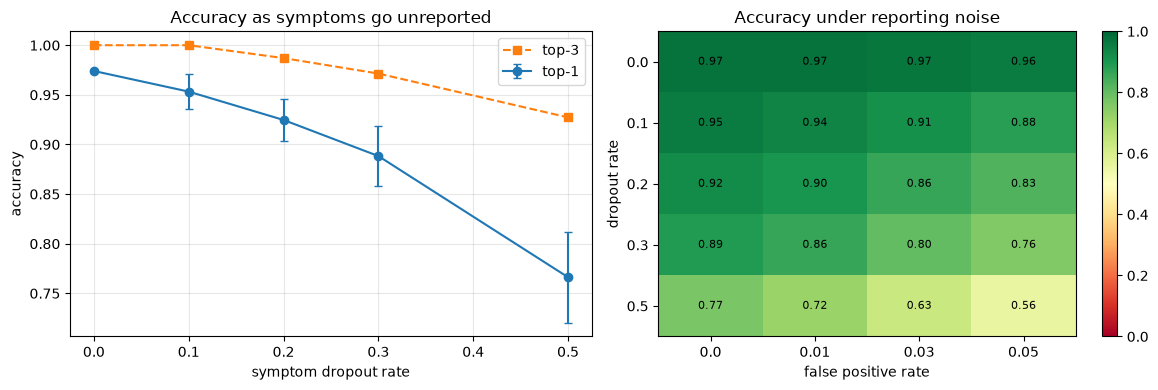

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clean = curve[curve.false_positive_rate == 0.0]
axes[0].errorbar(clean.dropout_rate, clean.accuracy_mean, yerr=clean.accuracy_std,
                 marker="o", capsize=3, label="top-1")
axes[0].plot(clean.dropout_rate, clean["top_3_accuracy_mean"], marker="s",
             linestyle="--", label="top-3")
axes[0].set_xlabel("symptom dropout rate")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy as symptoms go unreported")
axes[0].legend()
axes[0].grid(alpha=0.3)

grid = curve.pivot(index="dropout_rate", columns="false_positive_rate", values="accuracy_mean")
im = axes[1].imshow(grid.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_xticks(range(len(grid.columns)), grid.columns)
axes[1].set_yticks(range(len(grid.index)), grid.index)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("dropout rate")
axes[1].set_title("Accuracy under reporting noise")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        axes[1].text(j, i, f"{grid.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

In [14]:
baseline_accuracy = curve.query("dropout_rate == 0.0 and false_positive_rate == 0.0")["accuracy_mean"].iloc[0]
degraded = curve.query("dropout_rate == 0.3 and false_positive_rate == 0.03")

if not degraded.empty:
    degraded_accuracy = degraded["accuracy_mean"].iloc[0]
    degraded_top3 = degraded["top_3_accuracy_mean"].iloc[0]
    print(f"Clean input                       : {baseline_accuracy:.3f}")
    print(f"30% dropout + 3% false positives  : {degraded_accuracy:.3f}  ({degraded_accuracy - baseline_accuracy:+.3f})")
    print(f"  ...but top-3 accuracy holds at  : {degraded_top3:.3f}")
    print()
    print("Top-3 degrades far more gracefully than top-1. That is the argument for")
    print("presenting a ranked shortlist rather than a single confident verdict.")

Clean input                       : 0.974
30% dropout + 3% false positives  : 0.803  (-0.171)
  ...but top-3 accuracy holds at  : 0.953

Top-3 degrades far more gracefully than top-1. That is the argument for
presenting a ranked shortlist rather than a single confident verdict.


## 7. Explaining predictions

Two views: which symptoms matter *overall*, and which of *this patient's* symptoms drove
*this* answer. The second is computed by occlusion — switch one reported symptom off and
measure how far the probability falls.

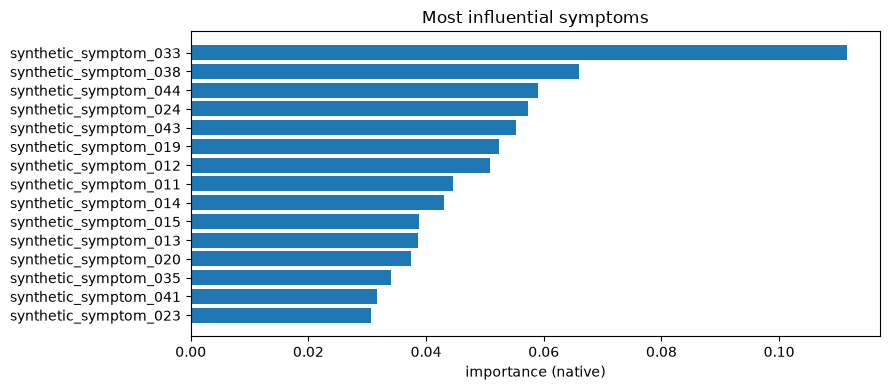

In [15]:
importance = global_importance(model, working.feature_names, top_n=15)

plt.barh(importance["symptom"][::-1], importance["importance"][::-1])
plt.xlabel(f"importance ({importance['method'].iloc[0]})")
plt.title("Most influential symptoms")
plt.tight_layout()
plt.show()

In [16]:
example_index = split.test[0]
reported = [name for name, flag in zip(working.feature_names, Xd[example_index]) if flag]
probabilities = model.predict_proba(Xd[example_index : example_index + 1])[0]
top_class = int(np.argmax(probabilities))
class_names = LabelEncoder().fit(working.labels).classes_

print(f"Reported symptoms : {', '.join(reported)}")
print(f"True disease      : {working.labels[example_index]}")
print(f"Predicted         : {class_names[top_class]} ({probabilities[top_class]:.1%})")
print("\nWhy:")
for contribution in explain_prediction(model, Xd[example_index], working.feature_names, top_n=5):
    if contribution.contribution > 0:
        print(f"  {contribution.symptom:<32} {contribution.share:>6.1%} of the evidence")

Reported symptoms : synthetic_symptom_021, synthetic_symptom_029, synthetic_symptom_034, synthetic_symptom_035, synthetic_symptom_037, synthetic_symptom_041
True disease      : Synthetic Condition 06
Predicted         : Synthetic Condition 06 (98.1%)

Why:
  synthetic_symptom_041             58.0% of the evidence
  synthetic_symptom_037             24.8% of the evidence
  synthetic_symptom_035             11.4% of the evidence
  synthetic_symptom_029              3.6% of the evidence
  synthetic_symptom_021              2.1% of the evidence


## 8. Conclusions

**On the dataset**

- It is close to a lookup table: symptom vectors map near-deterministically to diseases,
  so the accuracy ceiling genuinely is 100%.
- It repeats itself heavily. The effective sample size is the number of *distinct symptom
  patterns*, not the number of rows.
- It is exactly balanced across classes, which no real prevalence distribution is — and
  which makes imbalance handling pointless here.

**On the modelling**

- The reported 100% was a property of the evaluation protocol, not of the model. Once
  identical patterns are kept on one side of the split, the number becomes meaningful.
- A rule-based matcher with no learned parameters keeps pace with gradient boosting.
  On this task, the ensemble is not earning its complexity.
- Robustness to imperfect symptom reporting — not clean accuracy — is what actually
  distinguishes models here, and it is the number closest to real-world performance.

**On the method, which is the transferable part**

- Report the *protocol* with the number. On data with repeated rows, the protocol
  determines the number.
- Ship the baseline that might beat your model. That is what a baseline is for.
- Evaluate on the input the system will really receive, not only on the benchmark.

**What I would do differently with a real dataset**

- Group by *patient*, not by symptom pattern, and split temporally where possible.
- Model symptom severity, duration and onset rather than binary presence.
- Add an abstention path so the model can decline instead of guessing confidently
  outside its label set.
- Calibrate probabilities explicitly, and validate against a second cohort.

---

The pipeline shown here runs from the command line:

```bash
dp audit          # section 3
dp train          # sections 4-7, writing reports/
dp benchmark      # section 5
```